# DATA PREPARATION (MILESTONE 1)


## Import Library

In [ ]:
import pandas as pd
import numpy as np
from datetime import datetime
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
!pip install gdown
import gdown
import os

In [ ]:
pd.set_option('display.max_columns', None)

In [ ]:
import warnings
warnings.filterwarnings('ignore')

## Impor Dataset

In [ ]:
url = 'https://drive.google.com/file/d/1_xFUfSyvA3jgTBELM38KYo-7H2AIEO6y/view'

output = "User.csv"

gdown.download(url, output, quiet=False, fuzzy=True)

Downloading...
From: https://drive.google.com/uc?id=1_xFUfSyvA3jgTBELM38KYo-7H2AIEO6y
To: /content/User.csv
100%|██████████| 133k/133k [00:00<00:00, 49.2MB/s]


'User.csv'

In [ ]:
url = 'https://drive.google.com/file/d/1XWbRb5j-qvuaj3rpfhahIE0YojWfYANl/view'

output = "card.csv"

gdown.download(url, output, quiet=False, fuzzy=True)

Downloading...
From: https://drive.google.com/uc?id=1XWbRb5j-qvuaj3rpfhahIE0YojWfYANl
To: /content/card.csv
100%|██████████| 513k/513k [00:00<00:00, 113MB/s]


'card.csv'

In [ ]:
df_user_og = pd.read_csv('User.csv')

df_user_og.head()

,id,retirement_age,birthdate,gender,per_capita_income,yearly_income,total_debt,credit_score
0,825,66,1972-11-25,Female,Rp45.937.000,Rp93.663.000,Rp38.138.095,787
1,1746,68,1972-12-16,Female,Rp59.451.000,Rp121.212.000,Rp57.186.095,701
2,1718,67,1944-11-04,Female,Rp35.586.000,Rp52.535.000,Rp58.666,698
3,708,63,1963-01-12,Female,Rp255.975.000,Rp392.132.000,Rp60.467.238,722
4,1164,70,1982-09-21,Male,Rp84.407.000,Rp172.099.000,Rp54.946.285,675


In [ ]:
df_card_og = pd.read_csv('card.csv')

df_card_og.head()

,id,client_id,card_brand,card_number,expires,cvv,credit_limit,acct_open_date,year_pin_last_changed,days_since_last_trx,count_nonfraud_trx_L6M,amt_nonfraud_trx_L6M,count_fraud_trx_L6M,amt_fraud_trx_L6M
0,0,1362,Amex,393314135668401,04/2030,866,Rp53.189.000,01/1996,2019,17,181.0,Rp177.057.300,NaN,NaN
1,1,550,Mastercard,5278231764792292,06/2030,396,Rp18.200.000,01/1999,2018,27,148.0,Rp135.687.100,NaN,NaN
2,2,556,Mastercard,5889825928297675,09/2027,422,Rp31.298.000,01/2000,2016,20,415.0,Rp186.723.300,NaN,NaN
3,3,1937,Visa,4289888672554714,04/2026,736,Rp25.732.000,01/2000,2020,7,148.0,Rp207.881.500,NaN,NaN
4,4,1981,Mastercard,5433366978583845,03/2030,530,Rp30.500.000,01/2002,2012,14,48.0,Rp28.007.500,NaN,NaN


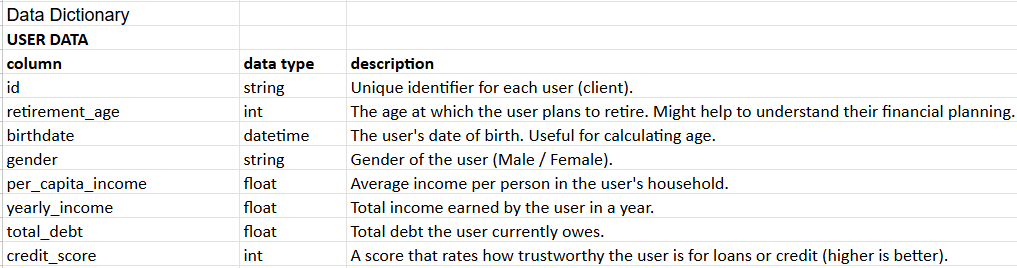

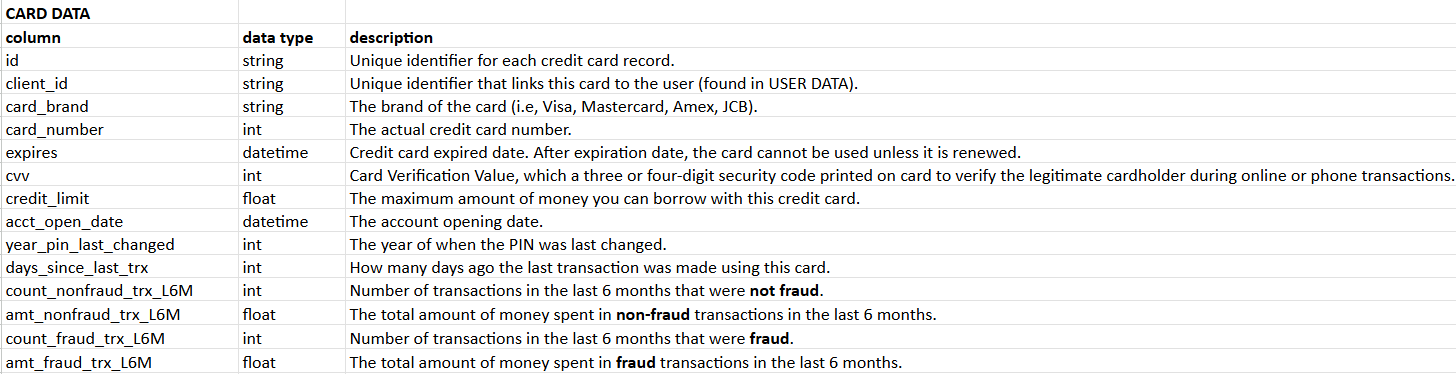

Resource :
https://docs.google.com/spreadsheets/d/1rAfYShrvCDVumiJSYZ9PXRVLCPEMhyWu/edit?usp=drive_link&ouid=114823175186658085244&rtpof=true&sd=true

## Goal Analysis

The goal of the analysis is to maximize business growth by identifying high-value transaction patterns, minimizing losses from fraud, and developing customer profiles to drive greater credit card usage.

# DATA CLEANING

## Data card

In [ ]:
df_card_dc = df_card_og.copy()

In [ ]:
df_card_dc.head()

,id,client_id,card_brand,card_number,expires,cvv,credit_limit,acct_open_date,year_pin_last_changed,days_since_last_trx,count_nonfraud_trx_L6M,amt_nonfraud_trx_L6M,count_fraud_trx_L6M,amt_fraud_trx_L6M
0,0,1362,Amex,393314135668401,04/2030,866,Rp53.189.000,01/1996,2019,17,181.0,Rp177.057.300,NaN,NaN
1,1,550,Mastercard,5278231764792292,06/2030,396,Rp18.200.000,01/1999,2018,27,148.0,Rp135.687.100,NaN,NaN
2,2,556,Mastercard,5889825928297675,09/2027,422,Rp31.298.000,01/2000,2016,20,415.0,Rp186.723.300,NaN,NaN
3,3,1937,Visa,4289888672554714,04/2026,736,Rp25.732.000,01/2000,2020,7,148.0,Rp207.881.500,NaN,NaN
4,4,1981,Mastercard,5433366978583845,03/2030,530,Rp30.500.000,01/2002,2012,14,48.0,Rp28.007.500,NaN,NaN


In [ ]:
df_card_dc.tail()

,id,client_id,card_brand,card_number,expires,cvv,credit_limit,acct_open_date,year_pin_last_changed,days_since_last_trx,count_nonfraud_trx_L6M,amt_nonfraud_trx_L6M,count_fraud_trx_L6M,amt_fraud_trx_L6M
5594,4508,1190,Visa,4227482000380763,07/2028,795,Rp7.301.000,09/2005,2012,5,320.0,Rp196.255.900,NaN,NaN
5595,209,1334,Visa,4144931322114018,02/2029,312,Rp14.592.000,01/2014,2014,32,41.0,Rp51.009.700,NaN,NaN
5596,2711,185,Visa,4718517475996018,01/2027,492,Rp8.943.000,04/2017,2017,14,198.0,Rp89.850.000,NaN,NaN
5597,1161,1891,Visa,4268017872699469,08/2031,476,Rp23.891.000,02/2013,2020,12,96.0,Rp43.768.500,NaN,NaN
5598,6115,921,Visa,4816027381867141,11/2029,163,Rp35.623.000,12/2020,2020,15,39.0,Rp53.889.900,NaN,NaN


In [ ]:
df_card_dc.shape

print("Number of rows : ", df_card_dc.shape[0])

print("Number of columns : ", df_card_dc.shape[1])

Number of rows :  5599
Number of columns :  14


### Check Data Type

In [ ]:
df_card_dc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5599 entries, 0 to 5598
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      5599 non-null   int64  
 1   client_id               5599 non-null   int64  
 2   card_brand              5599 non-null   object 
 3   card_number             5599 non-null   int64  
 4   expires                 5599 non-null   object 
 5   cvv                     5599 non-null   int64  
 6   credit_limit            5587 non-null   object 
 7   acct_open_date          5599 non-null   object 
 8   year_pin_last_changed   5599 non-null   int64  
 9   days_since_last_trx     5599 non-null   int64  
 10  count_nonfraud_trx_L6M  3707 non-null   float64
 11  amt_nonfraud_trx_L6M    3707 non-null   object 
 12  count_fraud_trx_L6M     547 non-null    float64
 13  amt_fraud_trx_L6M       547 non-null    object 
dtypes: float64(2), int64(6), object(6)
memor

In [ ]:
df_card_dc.isnull().sum()

,0
id,0
client_id,0
card_brand,0
card_number,0
expires,0
cvv,0
credit_limit,12
acct_open_date,0
year_pin_last_changed,0
days_since_last_trx,0


Insight :
1. id can be changed into string
2. client_id can be changed into string
3. expires can be changed into datetime
4. credit_limit can be changed to float
5. acct_open_date can be changed to datetime
6. count_nonfraud_trx_l6M can be changed to int64
7. amt_nonfraud_trx_L6M can be changed to float64
8. count_fraud_trx_L6M can be changed to int64
9. amt_fraud_trx_L6M can be changed to float64
10. credit_limit, 12 row null
11. count_nonfraud_trx_L6M, 1893 row null
12. amt_nonfraud_trx_L6M, 1892 row null
13. count_fraud_trx_L6M, 5052 row null
14. amt_fraud_trx_L6M, 5052 row null


### Convert Data Type

In [ ]:
df_card_dc['id'].astype(str)

,id
0,0
1,1
2,2
3,3
4,4
...,...
5594,4508
5595,209
5596,2711
5597,1161


In [ ]:
df_card_dc ['id'] = df_card_dc['id'].astype(str)

In [ ]:
df_card_dc['client_id'] = df_card_dc['client_id'].astype(str)

In [ ]:
df_card_dc['expires'] = pd.to_datetime(df_card_dc['expires'])

In [ ]:
def clean_currency(s):
    if isinstance(s, str):
        return float(s.replace('Rp', '').replace('.', ''))
    return s

In [ ]:
df_card_dc['credit_limit'] = df_card_dc['credit_limit'].apply(clean_currency).astype(float)

In [ ]:
df_card_dc['acct_open_date'] = pd.to_datetime(df_card_dc['acct_open_date'])

In [ ]:
df_card_dc['count_nonfraud_trx_L6M'] = df_card_dc['count_nonfraud_trx_L6M'].fillna(0).astype(int)

In [ ]:
df_card_dc['amt_nonfraud_trx_L6M'] = df_card_dc['amt_nonfraud_trx_L6M'].apply(clean_currency).astype(float)

In [ ]:
df_card_dc['count_fraud_trx_L6M'] = df_card_dc['count_fraud_trx_L6M'].fillna(0).astype(int)

In [ ]:
df_card_dc['amt_fraud_trx_L6M'] = df_card_dc['amt_fraud_trx_L6M'].apply(clean_currency).astype(float)

In [ ]:
df_card_dc.dtypes

,0
id,object
client_id,object
card_brand,object
card_number,int64
expires,datetime64[ns]
cvv,int64
credit_limit,float64
acct_open_date,datetime64[ns]
year_pin_last_changed,int64
days_since_last_trx,int64


In [ ]:
df_card_dc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5599 entries, 0 to 5598
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   id                      5599 non-null   object        
 1   client_id               5599 non-null   object        
 2   card_brand              5599 non-null   object        
 3   card_number             5599 non-null   int64         
 4   expires                 5599 non-null   datetime64[ns]
 5   cvv                     5599 non-null   int64         
 6   credit_limit            5587 non-null   float64       
 7   acct_open_date          5599 non-null   datetime64[ns]
 8   year_pin_last_changed   5599 non-null   int64         
 9   days_since_last_trx     5599 non-null   int64         
 10  count_nonfraud_trx_L6M  5599 non-null   int64         
 11  amt_nonfraud_trx_L6M    3707 non-null   float64       
 12  count_fraud_trx_L6M     5599 non-null   int64   

### Impute Missing Value

In [ ]:
df_card_dc['credit_limit'] = df_card_dc['credit_limit'].apply(clean_currency).fillna(0)

Insight:

The credit_limit value varies for each user and therefore cannot be imputed using the mean, median, or other estimation methods. Based on business assumptions, if the credit_limit field is empty, it indicates that the user does not have a credit facility, and thus the credit_limit is considered to be 0.


In [ ]:
df_card_dc['count_nonfraud_trx_L6M'] = df_card_dc['count_nonfraud_trx_L6M'].fillna(0)

Insight:

The missing values in count\_nonfraud\_trx\_L6M are filled with 0 because they most likely indicate that the user had no non-fraud transactions in the last six months. Therefore, a null value is considered equivalent to having no non-fraud transactions.

In [ ]:
df_card_dc['amt_nonfraud_trx_L6M'] = df_card_dc['amt_nonfraud_trx_L6M'].fillna(0)

For the amt\_nonfraud\_trx\_L6M column, missing values are filled with 0 because it is assumed that the customer had no non-fraud transactions in the last six months, making imputation with statistical values irrelevant.

In [ ]:
df_card_dc['count_fraud_trx_L6M'] = df_card_dc['count_fraud_trx_L6M'].fillna(0)

Insight:

For the count\_fraud\_trx\_L6M column, missing values are filled with 0 because it is assumed that the customer had no fraud transactions in the last six months, making statistical imputation unnecessary.

In [ ]:
df_card_dc['amt_fraud_trx_L6M'] = df_card_dc['amt_fraud_trx_L6M'].fillna(0)

Insight:

For the amt\_nonfraud\_trx\_L6M column, missing values are filled with 0 because it is assumed that the customer had no non-fraud transactions in the last six months, making statistical imputation irrelevant.

### Check Unique Values and Typo

In [ ]:
df_card_dc.columns

Index(['id', 'client_id', 'card_brand', 'card_number', 'expires', 'cvv',
       'credit_limit', 'acct_open_date', 'year_pin_last_changed',
       'days_since_last_trx', 'count_nonfraud_trx_L6M', 'amt_nonfraud_trx_L6M',
       'count_fraud_trx_L6M', 'amt_fraud_trx_L6M'],
      dtype='object')

In [ ]:
df_card_dc.dtypes

,0
id,object
client_id,object
card_brand,object
card_number,int64
expires,datetime64[ns]
cvv,int64
credit_limit,float64
acct_open_date,datetime64[ns]
year_pin_last_changed,int64
days_since_last_trx,int64


In [ ]:
for column_name in df_card_dc.select_dtypes(include=['object','int64']).columns:
    num_unique = df_card_dc[column_name].nunique()
    print(f"Number of unique values in {column_name}: {num_unique}")

Number of unique values in id: 5568
Number of unique values in client_id: 1942
Number of unique values in card_brand: 6
Number of unique values in card_number: 5568
Number of unique values in cvv: 997
Number of unique values in year_pin_last_changed: 19
Number of unique values in days_since_last_trx: 99
Number of unique values in count_nonfraud_trx_L6M: 589
Number of unique values in count_fraud_trx_L6M: 5


#### Show value_counts

In [ ]:
list_obj = ['card_brand', 'year_pin_last_changed',
            'days_since_last_trx', 'count_fraud_trx_L6M','count_nonfraud_trx_L6M']

for i in list_obj :
    unique_data = df_card_dc[i].value_counts()

    print(unique_data.to_frame().to_markdown(), '\n')


| card_brand   |   count |
|:-------------|--------:|
| Mastercard   |    2826 |
| Visa         |    2093 |
| Amex         |     402 |
| JCB          |     206 |
| Visa         |      69 |
| Jcb          |       3 | 

|   year_pin_last_changed |   count |
|------------------------:|--------:|
|                    2025 |    1083 |
|                    2016 |     734 |
|                    2015 |     657 |
|                    2017 |     435 |
|                    2018 |     432 |
|                    2014 |     404 |
|                    2019 |     374 |
|                    2020 |     318 |
|                    2013 |     278 |
|                    2021 |     218 |
|                    2012 |     163 |
|                    2022 |     145 |
|                    2023 |     134 |
|                    2024 |     100 |
|                    2011 |      65 |
|                    2010 |      36 |
|                    2008 |      11 |
|                    2009 |      10 |
|                    2

Insight:

1. Replace values in card_brand that has typos (fewer data instances)
2. Exclude data irrelevant
    1. Card Number (sensitive, not directly relevant for analysis)
    2. Cvv (sensitive, not directly relevant for analysis)

#### Treat Typos

###### Card Brand

In [ ]:
print((df_card_dc['card_brand'].value_counts()).to_markdown(), '\n')

| card_brand   |   count |
|:-------------|--------:|
| Mastercard   |    2826 |
| Visa         |    2093 |
| Amex         |     402 |
| JCB          |     206 |
| Visa         |      69 |
| Jcb          |       3 | 



In [ ]:
df_card_dc['card_brand'] = df_card_dc['card_brand'].str.strip()

In [ ]:
df_card_dc['card_brand'].replace("Visa","Visa", inplace = True)
df_card_dc['card_brand'].replace("Jcb","JCB", inplace = True)

In [ ]:
print((df_card_dc['card_brand'].value_counts()).to_markdown(), '\n')

| card_brand   |   count |
|:-------------|--------:|
| Mastercard   |    2826 |
| Visa         |    2162 |
| Amex         |     402 |
| JCB          |     209 | 



The typo errors in the card\_brand field for "Visa" and "Jcb" have been corrected.


#### Treat Irrelevant Data

###### card_number & cvv

In [ ]:
df_card_dc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5599 entries, 0 to 5598
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   id                      5599 non-null   object        
 1   client_id               5599 non-null   object        
 2   card_brand              5599 non-null   object        
 3   card_number             5599 non-null   int64         
 4   expires                 5599 non-null   datetime64[ns]
 5   cvv                     5599 non-null   int64         
 6   credit_limit            5599 non-null   float64       
 7   acct_open_date          5599 non-null   datetime64[ns]
 8   year_pin_last_changed   5599 non-null   int64         
 9   days_since_last_trx     5599 non-null   int64         
 10  count_nonfraud_trx_L6M  5599 non-null   int64         
 11  amt_nonfraud_trx_L6M    5599 non-null   float64       
 12  count_fraud_trx_L6M     5599 non-null   int64   

In [ ]:
df_card_dc.drop(columns = 'card_number', inplace = True)
df_card_dc.drop(columns = 'cvv', inplace = True)

In [ ]:
df_card_dc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5599 entries, 0 to 5598
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   id                      5599 non-null   object        
 1   client_id               5599 non-null   object        
 2   card_brand              5599 non-null   object        
 3   expires                 5599 non-null   datetime64[ns]
 4   credit_limit            5599 non-null   float64       
 5   acct_open_date          5599 non-null   datetime64[ns]
 6   year_pin_last_changed   5599 non-null   int64         
 7   days_since_last_trx     5599 non-null   int64         
 8   count_nonfraud_trx_L6M  5599 non-null   int64         
 9   amt_nonfraud_trx_L6M    5599 non-null   float64       
 10  count_fraud_trx_L6M     5599 non-null   int64         
 11  amt_fraud_trx_L6M       5599 non-null   float64       
dtypes: datetime64[ns](2), float64(3), int64(4), obje

Insight:

The card_number and cvv fields were excluded because they are irrelevant to the analysis and contain sensitive information.


In [ ]:
df_card_dc.isna().sum()

,0
id,0
client_id,0
card_brand,0
expires,0
credit_limit,0
acct_open_date,0
year_pin_last_changed,0
days_since_last_trx,0
count_nonfraud_trx_L6M,0
amt_nonfraud_trx_L6M,0


In [ ]:
df_card_dc.shape

(5599, 12)

In [ ]:
df_card_dc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5599 entries, 0 to 5598
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   id                      5599 non-null   object        
 1   client_id               5599 non-null   object        
 2   card_brand              5599 non-null   object        
 3   expires                 5599 non-null   datetime64[ns]
 4   credit_limit            5599 non-null   float64       
 5   acct_open_date          5599 non-null   datetime64[ns]
 6   year_pin_last_changed   5599 non-null   int64         
 7   days_since_last_trx     5599 non-null   int64         
 8   count_nonfraud_trx_L6M  5599 non-null   int64         
 9   amt_nonfraud_trx_L6M    5599 non-null   float64       
 10  count_fraud_trx_L6M     5599 non-null   int64         
 11  amt_fraud_trx_L6M       5599 non-null   float64       
dtypes: datetime64[ns](2), float64(3), int64(4), obje

insight:
1. All null's has been treated
2. All typo's has been treated

### Check Duplicates

In [ ]:
df_card_dc[df_card_dc.duplicated()]

,id,client_id,card_brand,expires,credit_limit,acct_open_date,year_pin_last_changed,days_since_last_trx,count_nonfraud_trx_L6M,amt_nonfraud_trx_L6M,count_fraud_trx_L6M,amt_fraud_trx_L6M
5568,2347,601,Visa,2030-11-01,8473000.0,2020-03-01,2020,29,29,24340700.0,0,0.0
5569,2720,73,Visa,2030-06-01,27068000.0,2018-04-01,2018,7,116,107706500.0,0,0.0
5570,2893,1759,Visa,2030-10-01,17259000.0,2010-05-01,2025,19,154,99452600.0,0,0.0
5571,5353,1561,Visa,2028-07-01,4271000.0,2002-11-01,2021,4,118,82179800.0,0,0.0
5572,4350,1123,Visa,2029-02-01,2187000.0,2015-08-01,2020,4,64,15806700.0,0,0.0
5573,3456,48,Visa,2030-03-01,15845000.0,2014-06-01,2018,8,168,76397900.0,0,0.0
5574,5515,1422,Visa,2031-07-01,10184000.0,2012-11-01,2018,3,99,41753200.0,0,0.0
5575,4867,157,Visa,2027-07-01,21084000.0,2015-01-01,2018,9,31,13155400.0,0,0.0
5576,4972,1308,Visa,2027-07-01,23221000.0,2007-10-01,2017,604,0,0.0,0,0.0
5577,1981,136,Visa,2029-08-01,38605000.0,2023-08-01,2025,604,0,0.0,0,0.0


Insight:

1. It shows that duplicate data exists, so we need to remove them based from card data

In [ ]:
df_card_dc.duplicated().sum()

np.int64(31)

In [ ]:
df_card_dc = df_card_dc.drop_duplicates()

In [ ]:
df_card_dc.duplicated().sum()

np.int64(0)

In [ ]:
df_card_dc.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5568 entries, 0 to 5567
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   id                      5568 non-null   object        
 1   client_id               5568 non-null   object        
 2   card_brand              5568 non-null   object        
 3   expires                 5568 non-null   datetime64[ns]
 4   credit_limit            5568 non-null   float64       
 5   acct_open_date          5568 non-null   datetime64[ns]
 6   year_pin_last_changed   5568 non-null   int64         
 7   days_since_last_trx     5568 non-null   int64         
 8   count_nonfraud_trx_L6M  5568 non-null   int64         
 9   amt_nonfraud_trx_L6M    5568 non-null   float64       
 10  count_fraud_trx_L6M     5568 non-null   int64         
 11  amt_fraud_trx_L6M       5568 non-null   float64       
dtypes: datetime64[ns](2), float64(3), int64(4), object(3)

### Filter Expired Cards & Zero Credit Limit

In [ ]:
(df_card_dc['expires'] < '2025-05-31').sum ()

np.int64(40)

In [ ]:
(df_card_dc['credit_limit'] == 0).sum ()

np.int64(37)

In [ ]:
df_card_dc = df_card_dc[(df_card_dc['expires'] > ('2025-05-31')) &(df_card_dc['credit_limit'] != 0)]

In [ ]:
(df_card_dc['expires'] < '2025-05-31').sum ()

np.int64(0)

In [ ]:
(df_card_dc['credit_limit'] == 0).sum ()

np.int64(0)

In [ ]:
df_card_dc.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5528 entries, 0 to 5567
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   id                      5528 non-null   object        
 1   client_id               5528 non-null   object        
 2   card_brand              5528 non-null   object        
 3   expires                 5528 non-null   datetime64[ns]
 4   credit_limit            5528 non-null   float64       
 5   acct_open_date          5528 non-null   datetime64[ns]
 6   year_pin_last_changed   5528 non-null   int64         
 7   days_since_last_trx     5528 non-null   int64         
 8   count_nonfraud_trx_L6M  5528 non-null   int64         
 9   amt_nonfraud_trx_L6M    5528 non-null   float64       
 10  count_fraud_trx_L6M     5528 non-null   int64         
 11  amt_fraud_trx_L6M       5528 non-null   float64       
dtypes: datetime64[ns](2), float64(3), int64(4), object(3)

Insight:

1. Cards that expired as of May 31, 2025, have been removed, as expired cards indicate that transactions can no longer occur. Therefore, they are excluded and considered outliers.
2. Cards with a credit limit of 0 have been removed, as they indicate that the customer has never used the card and is considered churned.



### Card Clean Data

In [ ]:
df_card = df_card_dc.copy()
df_card.head()

,id,client_id,card_brand,expires,credit_limit,acct_open_date,year_pin_last_changed,days_since_last_trx,count_nonfraud_trx_L6M,amt_nonfraud_trx_L6M,count_fraud_trx_L6M,amt_fraud_trx_L6M
0,0,1362,Amex,2030-04-01,53189000.0,1996-01-01,2019,17,181,177057300.0,0,0.0
1,1,550,Mastercard,2030-06-01,18200000.0,1999-01-01,2018,27,148,135687100.0,0,0.0
2,2,556,Mastercard,2027-09-01,31298000.0,2000-01-01,2016,20,415,186723300.0,0,0.0
3,3,1937,Visa,2026-04-01,25732000.0,2000-01-01,2020,7,148,207881500.0,0,0.0
4,4,1981,Mastercard,2030-03-01,30500000.0,2002-01-01,2012,14,48,28007500.0,0,0.0


In [ ]:
df_card.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5528 entries, 0 to 5567
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   id                      5528 non-null   object        
 1   client_id               5528 non-null   object        
 2   card_brand              5528 non-null   object        
 3   expires                 5528 non-null   datetime64[ns]
 4   credit_limit            5528 non-null   float64       
 5   acct_open_date          5528 non-null   datetime64[ns]
 6   year_pin_last_changed   5528 non-null   int64         
 7   days_since_last_trx     5528 non-null   int64         
 8   count_nonfraud_trx_L6M  5528 non-null   int64         
 9   amt_nonfraud_trx_L6M    5528 non-null   float64       
 10  count_fraud_trx_L6M     5528 non-null   int64         
 11  amt_fraud_trx_L6M       5528 non-null   float64       
dtypes: datetime64[ns](2), float64(3), int64(4), object(3)

## User Data

In [ ]:
# Copy of the original data for data cleaning
df_user_dc = df_user_og.copy()

In [ ]:
# Show 5 first data records
df_user_dc.head()

,id,retirement_age,birthdate,gender,per_capita_income,yearly_income,total_debt,credit_score
0,825,66,1972-11-25,Female,Rp45.937.000,Rp93.663.000,Rp38.138.095,787
1,1746,68,1972-12-16,Female,Rp59.451.000,Rp121.212.000,Rp57.186.095,701
2,1718,67,1944-11-04,Female,Rp35.586.000,Rp52.535.000,Rp58.666,698
3,708,63,1963-01-12,Female,Rp255.975.000,Rp392.132.000,Rp60.467.238,722
4,1164,70,1982-09-21,Male,Rp84.407.000,Rp172.099.000,Rp54.946.285,675


In [ ]:
# Check how much column and rows
# df_user_dc.shape
print('Number of rows is :', df_user_dc.shape[0])
print('Number of columns is :', df_user_dc.shape[1])

Number of rows is : 2000
Number of columns is : 8


### Check Data Type

In [ ]:
# Check table info
df_user_dc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   id                 2000 non-null   int64 
 1   retirement_age     2000 non-null   int64 
 2   birthdate          2000 non-null   object
 3   gender             2000 non-null   object
 4   per_capita_income  2000 non-null   object
 5   yearly_income      2000 non-null   object
 6   total_debt         2000 non-null   object
 7   credit_score       2000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 125.1+ KB


In [ ]:
df_user_dc.isnull().sum()

,0
id,0
retirement_age,0
birthdate,0
gender,0
per_capita_income,0
yearly_income,0
total_debt,0
credit_score,0


Insight:
1. id can be changed into string
2. birthdate can be changed into datetime
3. per_capita_income can be changed into float64
4. yearly_income can be changed into float64
5. total_debt can be changed into float64

### Convert Data Type

In [ ]:
# Mengubah Data type dari Int64 ke object (string)
df_user_dc ['id'] = df_user_dc['id'].astype(str)

In [ ]:
# Mengubah Data type dari object ke datetime
df_user_dc['birthdate'] = pd.to_datetime(df_user_dc['birthdate'])

In [ ]:
# untuk membersihkan "Rp" dan "." dari object agar bisa dikonversi ke float64
def clean_currency(s):
    if isinstance(s, str):
        return float(s.replace('Rp', '').replace('.', ''))
    return s

In [ ]:
# Mengubah Data type dari object ke float 64
df_user_dc['per_capita_income'] = df_user_dc['per_capita_income'].apply(clean_currency).fillna(0).astype(float)

In [ ]:
df_user_dc['yearly_income'] = df_user_dc['yearly_income'].apply(clean_currency).fillna(0).astype(float)

In [ ]:
df_user_dc['total_debt'] = df_user_dc['total_debt'].apply(clean_currency).fillna(0).astype(float)

In [ ]:
# pengecekan kembali kesesuaian dengan data dictionary
df_user_dc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   id                 2000 non-null   object        
 1   retirement_age     2000 non-null   int64         
 2   birthdate          2000 non-null   datetime64[ns]
 3   gender             2000 non-null   object        
 4   per_capita_income  2000 non-null   float64       
 5   yearly_income      2000 non-null   float64       
 6   total_debt         2000 non-null   float64       
 7   credit_score       2000 non-null   int64         
dtypes: datetime64[ns](1), float64(3), int64(2), object(2)
memory usage: 125.1+ KB


### Add Derive Columns

#### Columns Age

In [ ]:
# Penentuan cutoff date
cutoff_date = pd.to_datetime("2025-08-10")

In [ ]:
# Penghitungan umur
df_user_dc['age'] = (cutoff_date - df_user_dc['birthdate']).dt.days // 365


In [ ]:
# Pengecekan apakah kolom age telah bertambah
df_user_dc.head()

,id,retirement_age,birthdate,gender,per_capita_income,yearly_income,total_debt,credit_score,age
0,825,66,1972-11-25,Female,45937000.0,93663000.0,38138095.0,787,52
1,1746,68,1972-12-16,Female,59451000.0,121212000.0,57186095.0,701,52
2,1718,67,1944-11-04,Female,35586000.0,52535000.0,58666.0,698,80
3,708,63,1963-01-12,Female,255975000.0,392132000.0,60467238.0,722,62
4,1164,70,1982-09-21,Male,84407000.0,172099000.0,54946285.0,675,42


Insight:

An age column was added as an important variable for identifying suspicious transaction patterns and reducing potential fraud, while also enabling customer segmentation and offering tailored benefits to customers.


In [ ]:
df_user_dc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   id                 2000 non-null   object        
 1   retirement_age     2000 non-null   int64         
 2   birthdate          2000 non-null   datetime64[ns]
 3   gender             2000 non-null   object        
 4   per_capita_income  2000 non-null   float64       
 5   yearly_income      2000 non-null   float64       
 6   total_debt         2000 non-null   float64       
 7   credit_score       2000 non-null   int64         
 8   age                2000 non-null   int64         
dtypes: datetime64[ns](1), float64(3), int64(3), object(2)
memory usage: 140.8+ KB


#### Column Retired_flag

In [ ]:
# Pembuatan Kolom retired flag
df_user_dc['retired_flag'] = 0

In [ ]:
# penentuan retired_flag dengan ketentuan diatas 60 tahun sudah pensiun
df_user_dc.loc[df_user_dc['age'] >= 60, 'retired_flag'] = 1
print(df_user_dc['retired_flag'])

0       0
1       0
2       1
3       1
4       0
       ..
1995    0
1996    1
1997    0
1998    1
1999    0
Name: retired_flag, Length: 2000, dtype: int64


In [ ]:
df_user_dc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   id                 2000 non-null   object        
 1   retirement_age     2000 non-null   int64         
 2   birthdate          2000 non-null   datetime64[ns]
 3   gender             2000 non-null   object        
 4   per_capita_income  2000 non-null   float64       
 5   yearly_income      2000 non-null   float64       
 6   total_debt         2000 non-null   float64       
 7   credit_score       2000 non-null   int64         
 8   age                2000 non-null   int64         
 9   retired_flag       2000 non-null   int64         
dtypes: datetime64[ns](1), float64(3), int64(4), object(2)
memory usage: 156.4+ KB


Insight:

The retired_flag can be used to analyze transaction patterns for retired customers, as they tend to have lower and more stable transaction activity.


In [ ]:
# Pengecekan apakah kolom retired_flag sudah bertambah
df_user_dc.head()

,id,retirement_age,birthdate,gender,per_capita_income,yearly_income,total_debt,credit_score,age,retired_flag
0,825,66,1972-11-25,Female,45937000.0,93663000.0,38138095.0,787,52,0
1,1746,68,1972-12-16,Female,59451000.0,121212000.0,57186095.0,701,52,0
2,1718,67,1944-11-04,Female,35586000.0,52535000.0,58666.0,698,80,1
3,708,63,1963-01-12,Female,255975000.0,392132000.0,60467238.0,722,62,1
4,1164,70,1982-09-21,Male,84407000.0,172099000.0,54946285.0,675,42,0


#### Column DTI

In [ ]:
# untuk mendapatkan debt-to-income ratio dihitung dari total_debt / yearly_income
df_user_dc['DTI'] = df_user_dc['total_debt'] / df_user_dc['yearly_income']

print(df_user_dc['DTI'])

0       0.407184
1       0.471786
2       0.001117
3       0.154201
4       0.319271
          ...   
1995    0.348485
1996    0.403033
1997    0.437478
1998    0.094938
1999    0.523844
Name: DTI, Length: 2000, dtype: float64


In [ ]:
df_user_dc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   id                 2000 non-null   object        
 1   retirement_age     2000 non-null   int64         
 2   birthdate          2000 non-null   datetime64[ns]
 3   gender             2000 non-null   object        
 4   per_capita_income  2000 non-null   float64       
 5   yearly_income      2000 non-null   float64       
 6   total_debt         2000 non-null   float64       
 7   credit_score       2000 non-null   int64         
 8   age                2000 non-null   int64         
 9   retired_flag       2000 non-null   int64         
 10  DTI                2000 non-null   float64       
dtypes: datetime64[ns](1), float64(4), int64(4), object(2)
memory usage: 172.0+ KB


Insight:

The DTI is highly useful for assessing the financial health of customers applying for loans, helping to reduce the risk of default.


In [ ]:
df_user_dc.head()

,id,retirement_age,birthdate,gender,per_capita_income,yearly_income,total_debt,credit_score,age,retired_flag,DTI
0,825,66,1972-11-25,Female,45937000.0,93663000.0,38138095.0,787,52,0,0.407184
1,1746,68,1972-12-16,Female,59451000.0,121212000.0,57186095.0,701,52,0,0.471786
2,1718,67,1944-11-04,Female,35586000.0,52535000.0,58666.0,698,80,1,0.001117
3,708,63,1963-01-12,Female,255975000.0,392132000.0,60467238.0,722,62,1,0.154201
4,1164,70,1982-09-21,Male,84407000.0,172099000.0,54946285.0,675,42,0,0.319271


In [ ]:
df_user_dc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   id                 2000 non-null   object        
 1   retirement_age     2000 non-null   int64         
 2   birthdate          2000 non-null   datetime64[ns]
 3   gender             2000 non-null   object        
 4   per_capita_income  2000 non-null   float64       
 5   yearly_income      2000 non-null   float64       
 6   total_debt         2000 non-null   float64       
 7   credit_score       2000 non-null   int64         
 8   age                2000 non-null   int64         
 9   retired_flag       2000 non-null   int64         
 10  DTI                2000 non-null   float64       
dtypes: datetime64[ns](1), float64(4), int64(4), object(2)
memory usage: 172.0+ KB


### User Clean Data

In [ ]:
df_user = df_user_dc.copy()
df_user.head()

,id,retirement_age,birthdate,gender,per_capita_income,yearly_income,total_debt,credit_score,age,retired_flag,DTI
0,825,66,1972-11-25,Female,45937000.0,93663000.0,38138095.0,787,52,0,0.407184
1,1746,68,1972-12-16,Female,59451000.0,121212000.0,57186095.0,701,52,0,0.471786
2,1718,67,1944-11-04,Female,35586000.0,52535000.0,58666.0,698,80,1,0.001117
3,708,63,1963-01-12,Female,255975000.0,392132000.0,60467238.0,722,62,1,0.154201
4,1164,70,1982-09-21,Male,84407000.0,172099000.0,54946285.0,675,42,0,0.319271


In [ ]:
df_user_dc.to_csv('/content/df_user_dc.csv', index=False)

In [ ]:
df_card_dc.to_csv('/content/df_card_dc.csv', index=False)

# Merge Data

In [ ]:
# Merge the table
df_merged = df_card.merge(df_user, how='inner', left_on = ['client_id'], right_on = ['id'] )
df_merged.head()

,id_x,client_id,card_brand,expires,credit_limit,acct_open_date,year_pin_last_changed,days_since_last_trx,count_nonfraud_trx_L6M,amt_nonfraud_trx_L6M,count_fraud_trx_L6M,amt_fraud_trx_L6M,id_y,retirement_age,birthdate,gender,per_capita_income,yearly_income,total_debt,credit_score,age,retired_flag,DTI
0,0,1362,Amex,2030-04-01,53189000.0,1996-01-01,2019,17,181,177057300.0,0,0.0,1362,67,1968-01-24,Male,55798000.0,113768000.0,13244380.0,727,57,0,0.116416
1,1,550,Mastercard,2030-06-01,18200000.0,1999-01-01,2018,27,148,135687100.0,0,0.0,550,70,1950-02-25,Male,33293000.0,47459000.0,10688952.0,763,75,1,0.225225
2,2,556,Mastercard,2027-09-01,31298000.0,2000-01-01,2016,20,415,186723300.0,0,0.0,556,66,1979-12-12,Male,28016000.0,57119000.0,9508190.0,715,45,0,0.166463
3,3,1937,Visa,2026-04-01,25732000.0,2000-01-01,2020,7,148,207881500.0,0,0.0,1937,62,1961-02-12,Female,39774000.0,26761000.0,8700380.0,667,64,1,0.325114
4,4,1981,Mastercard,2030-03-01,30500000.0,2002-01-01,2012,14,48,28007500.0,0,0.0,1981,65,1978-01-24,Male,30241000.0,61666000.0,7068000.0,702,47,0,0.114617


In [ ]:
df_merged.tail()

,id_x,client_id,card_brand,expires,credit_limit,acct_open_date,year_pin_last_changed,days_since_last_trx,count_nonfraud_trx_L6M,amt_nonfraud_trx_L6M,count_fraud_trx_L6M,amt_fraud_trx_L6M,id_y,retirement_age,birthdate,gender,per_capita_income,yearly_income,total_debt,credit_score,age,retired_flag,DTI
5523,6141,715,Mastercard,2028-08-01,57378000.0,2022-08-01,2024,604,0,0.0,0,0.0,715,75,1989-01-07,Female,77187000.0,157375000.0,16114095.0,821,36,0,0.102393
5524,6142,1236,Mastercard,2030-11-01,19178000.0,2024-12-01,2024,604,0,0.0,0,0.0,1236,65,1953-09-06,Female,22978000.0,39606000.0,5381142.0,730,71,1,0.135867
5525,6143,253,Mastercard,2030-07-01,38739000.0,2024-12-01,2024,604,0,0.0,0,0.0,253,62,1965-01-15,Male,34055000.0,69439000.0,33049714.0,664,60,1,0.475953
5526,6144,737,Mastercard,2030-10-01,10355000.0,2024-12-01,2024,604,0,0.0,0,0.0,737,60,1964-03-28,Female,29750000.0,47633000.0,4946666.0,758,61,1,0.103850
5527,6145,682,Visa,2026-08-01,25178000.0,2020-08-01,2024,604,0,0.0,0,0.0,682,62,1967-10-02,Male,27106000.0,55274000.0,18213904.0,724,57,0,0.329520


In [ ]:
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5528 entries, 0 to 5527
Data columns (total 23 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   id_x                    5528 non-null   object        
 1   client_id               5528 non-null   object        
 2   card_brand              5528 non-null   object        
 3   expires                 5528 non-null   datetime64[ns]
 4   credit_limit            5528 non-null   float64       
 5   acct_open_date          5528 non-null   datetime64[ns]
 6   year_pin_last_changed   5528 non-null   int64         
 7   days_since_last_trx     5528 non-null   int64         
 8   count_nonfraud_trx_L6M  5528 non-null   int64         
 9   amt_nonfraud_trx_L6M    5528 non-null   float64       
 10  count_fraud_trx_L6M     5528 non-null   int64         
 11  amt_fraud_trx_L6M       5528 non-null   float64       
 12  id_y                    5528 non-null   object  

## Checking Outliers

<Axes: >

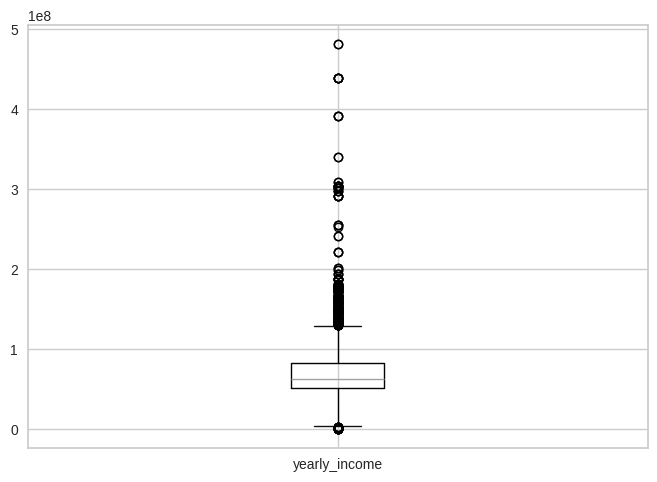

In [ ]:
# Cheking the data distribution of the df_merged data for yearly_income
df_merged[['yearly_income']].boxplot()

<Axes: >

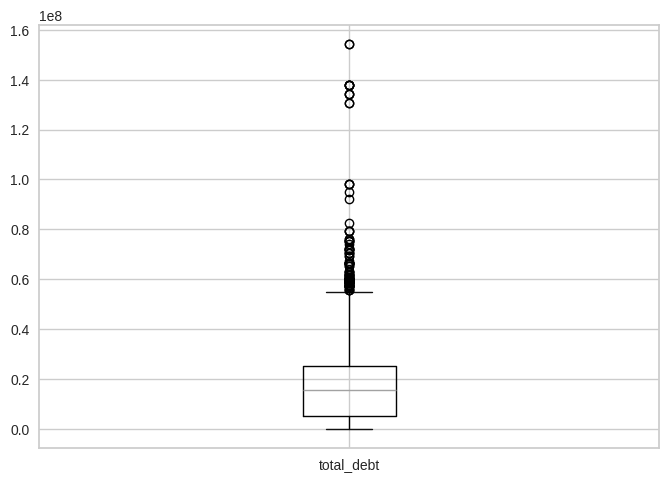

In [ ]:
# Cheking the data distribution of the df_merged data for total_debt
df_merged[['total_debt']].boxplot()

### Indetifyng outliers

In [ ]:
# Function for identifying and eliminating outliers from data
def remove_outliers(data, columns):
    data_check = data[columns]
    for i in data_check.columns:
        Q1 = data_check[i].quantile(0.25)
        Q3 = data_check[i].quantile(0.75)
        IQR = Q3 - Q1
        data = data[~((data_check[i] < (Q1 - 1.5 * IQR)) | (data_check[i] > (Q3 + 1.5 * IQR)))]
    return data

In [ ]:
# Remove outliers
df_clean = remove_outliers(df_merged, ['yearly_income', 'total_debt'])
df_clean

,id_x,client_id,card_brand,expires,credit_limit,acct_open_date,year_pin_last_changed,days_since_last_trx,count_nonfraud_trx_L6M,amt_nonfraud_trx_L6M,count_fraud_trx_L6M,amt_fraud_trx_L6M,id_y,retirement_age,birthdate,gender,per_capita_income,yearly_income,total_debt,credit_score,age,retired_flag,DTI
0,0,1362,Amex,2030-04-01,53189000.0,1996-01-01,2019,17,181,177057300.0,0,0.0,1362,67,1968-01-24,Male,55798000.0,113768000.0,13244380.0,727,57,0,0.116416
1,1,550,Mastercard,2030-06-01,18200000.0,1999-01-01,2018,27,148,135687100.0,0,0.0,550,70,1950-02-25,Male,33293000.0,47459000.0,10688952.0,763,75,1,0.225225
2,2,556,Mastercard,2027-09-01,31298000.0,2000-01-01,2016,20,415,186723300.0,0,0.0,556,66,1979-12-12,Male,28016000.0,57119000.0,9508190.0,715,45,0,0.166463
3,3,1937,Visa,2026-04-01,25732000.0,2000-01-01,2020,7,148,207881500.0,0,0.0,1937,62,1961-02-12,Female,39774000.0,26761000.0,8700380.0,667,64,1,0.325114
4,4,1981,Mastercard,2030-03-01,30500000.0,2002-01-01,2012,14,48,28007500.0,0,0.0,1981,65,1978-01-24,Male,30241000.0,61666000.0,7068000.0,702,47,0,0.114617
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5522,6140,545,Amex,2026-02-01,19926000.0,2020-02-01,2024,604,0,0.0,0,0.0,545,67,1970-10-27,Male,35171000.0,71714000.0,33828761.0,715,54,0,0.471718
5524,6142,1236,Mastercard,2030-11-01,19178000.0,2024-12-01,2024,604,0,0.0,0,0.0,1236,65,1953-09-06,Female,22978000.0,39606000.0,5381142.0,730,71,1,0.135867
5525,6143,253,Mastercard,2030-07-01,38739000.0,2024-12-01,2024,604,0,0.0,0,0.0,253,62,1965-01-15,Male,34055000.0,69439000.0,33049714.0,664,60,1,0.475953
5526,6144,737,Mastercard,2030-10-01,10355000.0,2024-12-01,2024,604,0,0.0,0,0.0,737,60,1964-03-28,Female,29750000.0,47633000.0,4946666.0,758,61,1,0.103850


In [ ]:
# Check the Q1,Q3,IQR,UB & LB
#ainc = yearly_income
print('Outlier Detection "yearly_income":\n')
ainc_Q1 = df_merged["yearly_income"].quantile(0.25)
print("Q1 =",ainc_Q1)

ainc_Q3 = df_merged["yearly_income"].quantile(0.75)
print("Q3 =",ainc_Q3)

ainc_IQR = ainc_Q3 - ainc_Q1
print("IQR =",ainc_IQR)

ainc_LB = ainc_Q1-1.5*ainc_IQR
print("LB =",ainc_LB)

ainc_UB = ainc_Q3+1.5*ainc_IQR
print("UB =",ainc_UB)
print('\n')

#lamnt = total_debt
print('Outlier Detection "total_debt":\n')
lamnt_Q1 = df_merged["total_debt"].quantile(0.25)
print("Q1 =",lamnt_Q1)

lamnt_Q3 = df_merged["total_debt"].quantile(0.75)
print("Q3 =",lamnt_Q3)

lamnt_IQR = lamnt_Q3 - lamnt_Q1
print("IQR =",lamnt_IQR)

lamnt_LB = lamnt_Q1-1.5*lamnt_IQR
print("LB =",lamnt_LB)

lamnt_UB = lamnt_Q3+1.5*lamnt_IQR
print("UB =",lamnt_UB)

Outlier Detection "yearly_income":

Q1 = 50712250.0
Q3 = 82184000.0
IQR = 31471750.0
LB = 3504625.0
UB = 129391625.0


Outlier Detection "total_debt":

Q1 = 5180809.25
Q3 = 25125904.0
IQR = 19945094.75
LB = -24736832.875
UB = 55043546.125


In [ ]:
# Removing/excluding the outlier and assign it on new variable "df_clean"
df_clean_annual_inc = df_merged[~((df_merged["yearly_income"] < ainc_LB) | (df_merged["yearly_income"] > ainc_UB))]
df_clean = df_clean_annual_inc[~((df_clean_annual_inc["total_debt"] < lamnt_LB) | (df_clean_annual_inc["total_debt"] > lamnt_UB))]
df_clean.shape

(5188, 23)

<Axes: xlabel='yearly_income'>

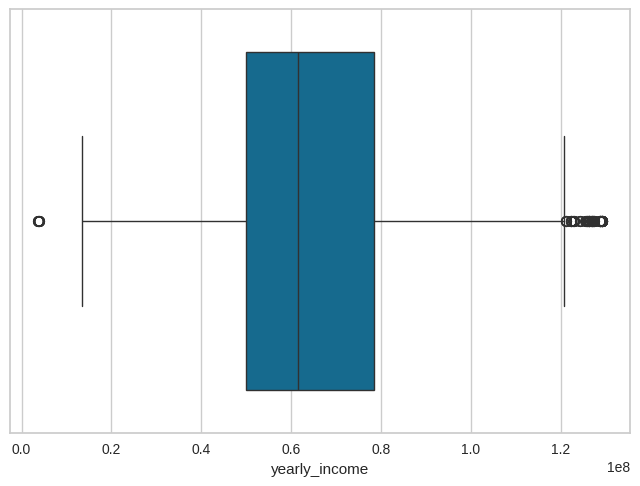

In [ ]:
# Cheking the data distribution of the df_merged data for yearly_income
sns.boxplot(data = df_clean , x ="yearly_income")

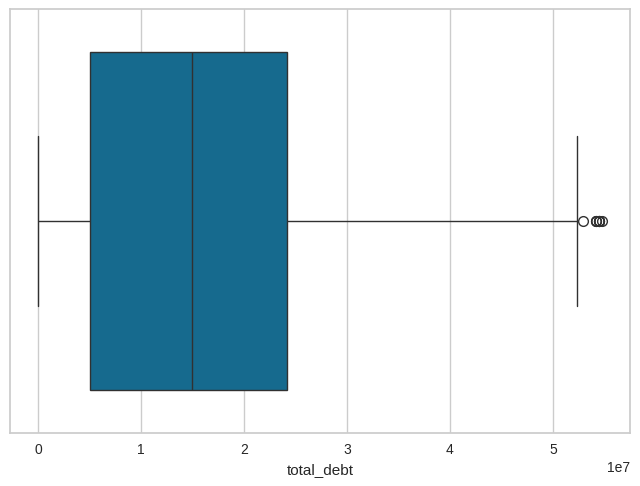

In [ ]:
# Cheking the data distribution of the df_merged data for total_debt
loan_amnt_box = sns.boxplot(data = df_clean , x ="total_debt")

# EXPLORATORY DATA ANALYSIS (MILESTONE 2)

## Calculate the total net profit

In [ ]:
# Hitung total sales amount per baris
df_merged['total_sales_amount'] = (
    df_merged['amt_nonfraud_trx_L6M'] + df_merged['amt_fraud_trx_L6M']
)

# Hitung MDR fee profit per baris (1.5% * total sales amount)
df_merged['MDR_fee_profit'] = 0.015 * df_merged['amt_nonfraud_trx_L6M']

# Hitung total fraud amount (agregat)
total_fraud = df_merged['amt_fraud_trx_L6M'].sum()

# Hitung total MDR fee profit (agregat)
total_mdr_fee_profit = df_merged['MDR_fee_profit'].sum()

# Hitung total net profit
total_net_profit = total_mdr_fee_profit - total_fraud

# Hitung Net Profit Margin
net_profit_margin = (total_net_profit / total_mdr_fee_profit) * 100

# Print hasil
print(f"Total Net Profit (6 months) = {total_net_profit:,.2f}")
print(f"Net Profit Margin (6 months) = {net_profit_margin:.2f}%")
print(f"total_fraud(6 months) = {total_fraud:,.2f}")

# Data untuk bar chart
categories = ['Net Profit', 'Fraud']
values = [total_net_profit, total_fraud]
colors = ['#4E79A7', '#F28E2B']

plt.figure(figsize=(8,6))
plt.bar(categories, values, color=colors)
plt.title('Net Profit vs Fraud (6 months)', fontsize=14)
plt.ylabel('Amount (Rp)', fontsize=12)
plt.xlabel('Category', fontsize=12)

# Tambahkan label nilai di atas bar
for i, v in enumerate(values):
    plt.text(i, v + (0.02 * max(values)), f"Rp{v:,.0f}", ha='center', fontsize=10)

plt.show()

NameError: name 'df_merged' is not defined

Insight:

Net profit earned by NexaPay over a six‑month period, after deducting potential fraud.

## Calculate the fraud rate

In [ ]:
# Total transaksi semua user
total_sales = df_merged['total_sales_amount'].sum()

# Total fraud semua user
total_fraud = df_merged['amt_fraud_trx_L6M'].sum()

# Hitung fraud rate
fraud_rate = total_fraud / total_sales
print(f"Fraud Rate (6 Months) = {fraud_rate:.2%}")

# Visualisasi dengan pie chart
fraud_data = {
    'Fraud': total_fraud,
    'Non-Fraud': total_sales - total_fraud
}

plt.figure(figsize=(6,6))
plt.pie(fraud_data.values(), labels=list(fraud_data.keys()),
autopct='%1.2f%%')
plt.title('Fraud vs Non-Fraud Transaction Amount (6 Months)')
plt.show()


Insight:

Based on the fraud ratio over the past six months of just 0.22%, it can be inferred that the current fraud control and prevention processes are highly effective. Nevertheless, there remains room for improvement through deeper analysis of fraud patterns and enhanced education for both customers and internal teams to raise awareness.

## Difference in transaction behavior per Card Brand

In [ ]:
# Total count transaksi
df_merged['total_trx_count'] = (
    df_merged['count_nonfraud_trx_L6M']
)

# Total amount transaksi
df_merged['total_trx_amount'] = (
    df_merged['amt_nonfraud_trx_L6M']
)

# Rata-rata transaksi dan Group by card brand
card_brand_summary = df_merged.groupby('card_brand').agg({
    'total_trx_count': 'mean',
    'total_trx_amount': 'mean'
}).reset_index()

# Definisikan warna tetap per brand
brand_colors = {
    "Mastercard": "#4E79A7",
    "Visa": "#F28E2B",
    "Amex": "#E15759",
    "JCB": "#76B7B2"
}

# Visualisasi Chart Transaction count
card_brand_summary_sorted = card_brand_summary.sort_values("total_trx_count", ascending=False)

plt.figure(figsize=(10,6))
bars = plt.bar(
    card_brand_summary_sorted['card_brand'],
    card_brand_summary_sorted['total_trx_count'],
    color=card_brand_summary_sorted['card_brand'].map(brand_colors)
)
plt.title('Average Transaction Count per Card Brand')
plt.xlabel('Card Brand')
plt.ylabel('Avg Transaction Count')

plt.bar_label(bars, fmt="%.0f", fontsize=9)
plt.show()
print("\n")

# Visualisasi Chart Transaction amount
card_brand_summary_sorted = card_brand_summary.sort_values("total_trx_amount", ascending=False)

plt.figure(figsize=(10,6))
bars = plt.bar(
    card_brand_summary_sorted['card_brand'],
    card_brand_summary_sorted['total_trx_amount'],
    color=card_brand_summary_sorted['card_brand'].map(brand_colors)
)
plt.title('Average Transaction Amount per Card Brand')
plt.xlabel('Card Brand')
plt.ylabel('Avg Transaction Amount')

plt.bar_label(bars, fmt="%.0f", fontsize=9)
plt.show()

Insight:

Mastercard – The most frequently used card, driving transaction volume; targeted promotions in retail and dining can further strengthen usage and revenue.

Amex – Leads in transaction value, confirming its premium positioning; exclusive benefits at high-end retail and airports can sustain high-value spending.

JCB – The weakest across both frequency and value; requires stronger marketing and awareness initiatives before pursuing broader growth.

Risk Consideration – Higher transaction activity boosts revenue potential but also raises fraud exposure; Mastercard and Visa need tighter monitoring due to volume, while Amex carries higher impact risk per transaction.

## DTI ratio retired vs non-retired

In [ ]:
# Deskripsi Statistik
dti_stats = (df_merged.groupby("retired_flag")["DTI"]
             .describe()[["count","mean","50%","std","min","max"]]
             .rename(columns={"50%":"median"}))
dti_stats


In [ ]:
def risk_category(dti):
    if dti < 0.3:
        return "Low"
    elif dti < 0.6:
        return "Medium"
    else:
        return "High"

df_merged["risk_level"] = df_merged["DTI"].apply(risk_category)

df_merged.groupby(["retired_flag","risk_level"]).size().unstack()

# sns.countplot(data=df_merged, x="risk_level", hue="retired_flag", order=["Low","Medium","High"])
# plt.title("Distribusi Risk Level: Pensiunan vs Non-Pensiunan")
# plt.xlabel("Risk Level")
# plt.ylabel("Jumlah Nasabah")
# plt.show()

# order = ["Low", "Medium", "High"]

# sns.catplot(
#     data=df_merged,
#     x="card_brand", hue="risk_level",
#     col="retired_flag",
#     kind="count", order = df_merged["card_brand"].value_counts().index,
#     hue_order = order,
#     height=5, aspect=1.4
# )
# plt.xticks(rotation=45)
# plt.subplots_adjust(top=0.8)
# plt.suptitle("Distribusi Risk Level per Card Brand, Pensiunan vs Non-Pensiunan")
# plt.show()

risk_pct = (
    df_merged.groupby(["retired_flag","card_brand","risk_level"])
             .size()
             .groupby(level=[0,1])
             .apply(lambda s: 100*s/s.sum())
             .unstack(fill_value=0)
)

# Simpan hasil plot ke ax
ax = risk_pct.plot(kind="bar", stacked=True, figsize=(10,6))

ax.set_title("Persentase Risk Level per Card Brand (Pensiunan vs Non)")
ax.set_ylabel("Persentase (%)")
plt.xticks(rotation=60)
plt.legend(title="Risk Level", bbox_to_anchor=(1.02,1), loc="upper left")

# Tambahkan label persen di tengah bar
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", label_type="center", fontsize=8, color="black")

plt.tight_layout()
plt.show()


In [ ]:
# Visualisasi dengan Box Plot
plt.figure(figsize=(10,6))
df_merged.boxplot(column="DTI", by="retired_flag")
plt.title("DTI: Retired vs Non-retired")
plt.suptitle("")
plt.ylabel("Debt-to-Income Ratio")
plt.show()


NameError: name 'plt' is not defined

Insight:

1.The DTI range for non retired users is wider, with more high-value outliers above 0.8, indicating greater variability and potentially higher risk in certain subgroups. Introduce special loan application promotions for non retired customers, offering lower interest rates and partial repayment discounts within a defined loan term, to attract quality borrowers and mitigate risk in higher DTI subgroups.

2.Retired users tend to have lower DTI overall, possibly due to reduced borrowing capacity or smaller outstanding debts. Launch short term loan promotions targeted at retired customers to meet immediate financing needs while maintaining manageable repayment commitments.

In [ ]:
# copy df_merged sebelum agregat untuk checkpoint 3
df_client = df_merged.copy()

In [ ]:
# membuat kolom recency sebagai hari terakhir transaksi
df_merged['recency'] = df_merged['days_since_last_trx']

In [ ]:
# Membuat kolom monetary sebagai total dari beberapa kolom transaksi
df_merged['monetary'] = df_merged['amt_nonfraud_trx_L6M']
df_merged['frequency'] = df_merged['count_nonfraud_trx_L6M']

In [ ]:
# Membuat dataframe baru
df_rfm = df_merged.groupby('client_id', as_index=False).agg({
    'monetary': 'sum',
    'frequency': 'sum',
    'recency': 'min'
})

In [ ]:
df_rfm.head()

## Average DTI by Credit Score Category

In [ ]:
df_client.info()

In [ ]:
# Kelompok nilai credit_score
bins   = [300, 580, 670, 740, 800, 850]
labels = ['Fair','Poor','Good','Very Good','Exceptional']

df_client['credit_score_cat'] = pd.cut(
    df_client['credit_score'], bins=bins, labels=labels, include_lowest=True, right=True
)

# Di urut berdasarkan sesuai labels bukan alphabet
df_client['credit_score_cat'] = df_client['credit_score_cat'].astype(pd.CategoricalDtype(categories=labels, ordered=True))

print(df_client['credit_score_cat'])

In [ ]:
# menghitung rata rata DTI dan di group menggunakan Credit Score Category
credit_score_summary = (df_client
         .groupby('credit_score_cat', observed=True)
         .agg(avg_DTI=('DTI','mean'),
              avg_trx_count=('total_trx_count','mean'),
              avg_trx_amount=('total_trx_amount','mean'),
              n_users=('client_id','nunique') if 'client_id' in df_client.columns else ('DTI','count'))
         .reset_index())

credit_score_summary


In [ ]:
# Penambahan Warna
colors = ['#4E79A7', '#F28E2B', '#E15759', '#76B7B2', '#59A14F']

# Visualisasi Data Rata-rata DTI per kategori
plt.figure(figsize=(10,6))
bars = plt.bar(
    credit_score_summary['credit_score_cat'],
    credit_score_summary['avg_DTI'],
    color=colors
)
plt.title('Average DTI by Credit Score Category')
plt.xlabel('Credit Score Category')
plt.ylabel('Average DTI')
plt.bar_label(bars, fmt="%.2f", fontsize=9)   # pakai 2 desimal untuk DTI
plt.show()
print("\n")

# --- Chart 2: Avg Transaction Count ---
plt.figure(figsize=(10,6))
bars = plt.bar(
    credit_score_summary['credit_score_cat'],
    credit_score_summary['avg_trx_count'],
    color=colors
)
plt.title('Average Transaction Count (L6M) by Credit Score Category')
plt.xlabel('Credit Score Category')
plt.ylabel('Average Transaction Count')
plt.bar_label(bars, fmt="%.0f", fontsize=9)   # bulatkan count
plt.show()
print("\n")

# --- Chart 3: Avg Transaction Amount ---
plt.figure(figsize=(10,6))
bars = plt.bar(
    credit_score_summary['credit_score_cat'],
    credit_score_summary['avg_trx_amount'],
    color=colors
)
plt.title('Average Transaction Amount (L6M) by Credit Score Category')
plt.xlabel('Credit Score Category')
plt.ylabel('Average Transaction Amount')
plt.bar_label(bars, fmt="%.0f", fontsize=9)   # bulatkan nominal
plt.show()


NameError: name 'plt' is not defined

Recommendation :


The high DTI and transaction volume in the Fair and Poor segments indicate a potential risk of default, but also a significant revenue opportunity. The solution is for the bank to implement adaptive credit limit controls and ontime payment reward programs to reduce risk while maintaining transaction levels. For the Very Good and Exceptional segments, the bank can offer low risk usage promotions such as cashback to increase utilization without adding credit risk.


## Relationship between user age and credit limit

In [ ]:
# pake fungsi if untuk mempermudah penyusunan
age_col = 'age' if 'age' in df_client.columns else 'user_age'
limit_col = 'credit_limit'

# Buang baris yang tidak punya age / credit_limit
df_age = df_client.dropna(subset=[age_col, limit_col]).copy()

# Age ambil 'first' (harusnya konsisten per user)
# Credit limit dijumlah (kalau user punya beberapa kartu)
user_limit = (df_age
              .groupby('client_id', as_index=False)
              .agg(user_age=(age_col, 'first'),
                   credit_limit_total=(limit_col, 'sum')))

In [ ]:
# Pengelompokkan segment umur
bins   = [18, 24, 29, 34, 39, 44, 49, 54, 59, 64, 69]
labels = ['18–24','25–29','30–34','35–39','40–44','45–49','50–54','55–59','60–64','65+']

user_limit['age_segment'] = pd.cut(user_limit['user_age'], bins=bins, labels=labels, include_lowest=True, right=True)

band_limit = (user_limit
              .dropna(subset=['age_segment'])
              .groupby('age_segment', observed=True)
              .agg(avg_credit_limit=('credit_limit_total', 'mean'),
                   median_credit_limit=('credit_limit_total', 'median'),
                   n_users=('credit_limit_total','size'))
              .reset_index())

# Visualisasi rata-rata credit limit per age segment
plt.figure(figsize=(10,6))
plt.plot(band_limit['age_segment'].astype(str), band_limit['avg_credit_limit'], marker='o')
plt.title('Average Credit Limit by Age Band')
plt.xlabel('Age Segment')
plt.ylabel('Average Credit Limit')
plt.grid(True, linestyle='solid', alpha=0.6)
plt.show()



Insight:

Average credit limit increases steadily with age, peaking in the 65+ segment, while the 18–24 segment has the lowest limits. This suggests that younger customers may face barriers to higher utilization due to limited credit capacity. The bank can address this by gradually increasing limits for low-risk younger customers to boost engagement, while maintaining prudent limit management for older segments to protect profitability and control risk.

Recommendation:

The '30–45' age group, with financial stability and moderate credit limits, offers strong potential for increased card usage. Targeted promotions such as cashback, travel perks, or installment discounts can stimulate engagement in this segment. Younger low-risk customers can receive gradual limit increases, while older segments maintain prudent limit management to control risk.


# CUSTOMER SEGMENTATION (MILESTONE 3)

## RFM

I chose RFM because the primary goal is to identify customers who are under-transacting based on actual behavior. With the available last-6-months (L6M) non-fraud data (R, F, M), RFM provides segmentation that is easy to understand, quick to implement, and immediately actionable for frequency-uplift campaigns.

Easy to explain & execute for the CRM team
Segment mapping (e.g., Champions, Loyal, Need Attention, Hibernating) is intuitive for defining tactics: onboarding, reactivation, cross/upsell, or loyalty. Implementation is fast (simple 1–5 scoring).

Simple operations & monitoring
Scores can be calculated monthly using an L6M window, then tracked by segment: number of customers, repeat rate, AOV (Average Order Value), and revenue contribution—making campaign A/B testing easier.

In [ ]:
# membuat kolom recency sebagai hari terakhir transaksi
df_merged['recency'] = df_merged['days_since_last_trx']

In [ ]:
# Membuat kolom monetary sebagai revenue bersih
df_merged['monetary'] = df_merged['amt_nonfraud_trx_L6M']

In [ ]:
# membuat kolom frequency sebagai jumlah transasksi
df_merged['frequency'] = df_merged['count_nonfraud_trx_L6M']

In [ ]:
# Membuat dataframe baru
df_rfm = df_merged.groupby('client_id', as_index=False).agg({
    'monetary': 'sum',
    'frequency': 'sum',
    'recency': 'min'
})

In [ ]:
df_rfm.head()

,client_id,monetary,frequency,recency
0,0,535262100.0,685,3
1,1,264007900.0,498,20
2,10,0.0,0,604
3,100,295701900.0,366,5
4,1000,0.0,0,604


## RFM Segments

### Recency

In [ ]:
pd.qcut(df_rfm['recency'], q=5, duplicates='drop')

,recency
0,"(-0.001, 4.0]"
1,"(10.0, 26.0]"
2,"(26.0, 604.0]"
3,"(4.0, 10.0]"
4,"(26.0, 604.0]"
...,...
1933,"(26.0, 604.0]"
1934,"(-0.001, 4.0]"
1935,"(-0.001, 4.0]"
1936,"(26.0, 604.0]"


### Frequency

In [ ]:
pd.qcut(df_rfm['frequency'], q=5, duplicates='drop')

,frequency
0,"(604.6, 2535.0]"
1,"(410.0, 604.6]"
2,"(-0.001, 159.6]"
3,"(159.6, 410.0]"
4,"(-0.001, 159.6]"
...,...
1933,"(-0.001, 159.6]"
1934,"(604.6, 2535.0]"
1935,"(604.6, 2535.0]"
1936,"(-0.001, 159.6]"


### Monetary

In [ ]:
pd.qcut(df_rfm['monetary'], q=5, duplicates='drop').value_counts()

,count
monetary,
"(-0.001, 91096420.0]",775
"(91096420.0, 259092740.0]",388
"(420668600.0, 2011022300.0]",388
"(259092740.0, 420668600.0]",387


## Scoring the R-F-M

In [ ]:
# memberikan score kepada variable R-F-M
df_rfm['r_score'] = pd.qcut(df_rfm['recency'], q=5, duplicates='drop', labels=[5,4,3,2])
df_rfm['f_score'] = pd.qcut(df_rfm['frequency'], q=5, duplicates='drop', labels=[2,3,4,5])
df_rfm['m_score'] = pd.qcut(df_rfm['monetary'], q=5, duplicates='drop', labels=[2,3,4,5])
df_rfm

,client_id,monetary,frequency,recency,R_score,r_score,f_score,m_score
0,0,535262100.0,685,3,5,5,5,5
1,1,264007900.0,498,20,3,3,4,4
2,10,0.0,0,604,1,2,2,2
3,100,295701900.0,366,5,4,4,3,4
4,1000,0.0,0,604,1,2,2,2
...,...,...,...,...,...,...,...,...
1933,995,0.0,0,604,2,2,2,2
1934,996,570563000.0,871,0,5,5,5,5
1935,997,674910900.0,1178,2,5,5,5,5
1936,998,0.0,0,604,2,2,2,2


In [ ]:
# Combine all scores dan semua data diubah ke datatype str
df_rfm['rfm_score'] = df_rfm['r_score'].astype(str) + df_rfm['f_score'].astype(str) + df_rfm['m_score'].astype(str)
df_rfm

,client_id,monetary,frequency,recency,R_score,r_score,f_score,m_score,rfm_score
0,0,535262100.0,685,3,5,5,5,5,555
1,1,264007900.0,498,20,3,3,4,4,344
2,10,0.0,0,604,1,2,2,2,222
3,100,295701900.0,366,5,4,4,3,4,434
4,1000,0.0,0,604,1,2,2,2,222
...,...,...,...,...,...,...,...,...,...
1933,995,0.0,0,604,2,2,2,2,222
1934,996,570563000.0,871,0,5,5,5,5,555
1935,997,674910900.0,1178,2,5,5,5,5,555
1936,998,0.0,0,604,2,2,2,2,222


# Interpreting RFM Segments

In [ ]:
df_rfm['rfm_score'].value_counts()

,count
rfm_score,
222,744
555,113
333,97
433,82
455,76
355,70
533,69
544,65
444,59


In [ ]:
GSHEET_URL = 'https://docs.google.com/spreadsheets/d/1xbxOTeE6ihnp6iBA_yz1mJimR-z2sAEDQNkQ4crh92E/edit?gid=884117664#gid=884117664'
GSHEET_URL_CSV = GSHEET_URL.replace('/edit?gid=', '/export?format=csv&gid=')
rfm_segments = pd.read_csv(GSHEET_URL_CSV)

# Ubah score menjadi string agar bisa dijoin dengan data
rfm_segments['rfm_score'] = rfm_segments['rfm_score'].astype(str)
rfm_segments

,rfm_score,segment,Activity,Actionable
0,555,Champions,"Bought recently, buy often and spend the most!",Reward them. Can be early adopters for new pro...
1,554,Champions,"Bought recently, buy often and spend the most!",Reward them. Can be early adopters for new pro...
2,544,Champions,"Bought recently, buy often and spend the most!",Reward them. Can be early adopters for new pro...
3,545,Champions,"Bought recently, buy often and spend the most!",Reward them. Can be early adopters for new pro...
4,454,Champions,"Bought recently, buy often and spend the most!",Reward them. Can be early adopters for new pro...
...,...,...,...,...
120,112,Lost,"Lowest recency, frequency and monetary scores.","Revive interest with reach out campaign, ignor..."
121,121,Lost,"Lowest recency, frequency and monetary scores.","Revive interest with reach out campaign, ignor..."
122,131,Lost,"Lowest recency, frequency and monetary scores.","Revive interest with reach out campaign, ignor..."
123,141,Lost,"Lowest recency, frequency and monetary scores.","Revive interest with reach out campaign, ignor..."


In [ ]:
rfm_final = df_rfm.merge(rfm_segments, how='left', on='rfm_score')
rfm_final

,client_id,monetary,frequency,recency,R_score,r_score,f_score,m_score,rfm_score,segment,Activity,Actionable
0,0,535262100.0,685,3,5,5,5,5,555,Champions,"Bought recently, buy often and spend the most!",Reward them. Can be early adopters for new pro...
1,1,264007900.0,498,20,3,3,4,4,344,Loyal Customers,Spend good money with us often. Responsive to ...,Upsell higher value products. Ask for reviews....
2,10,0.0,0,604,1,2,2,2,222,Hibernating,"Last purchase was long back, low spenders and ...",Offer other relevant products and special disc...
3,100,295701900.0,366,5,4,4,3,4,434,Customers Needing Attention,"Above average recency, frequency and monetary ...","Make limited time offers, Recommend based on p..."
4,1000,0.0,0,604,1,2,2,2,222,Hibernating,"Last purchase was long back, low spenders and ...",Offer other relevant products and special disc...
...,...,...,...,...,...,...,...,...,...,...,...,...
1933,995,0.0,0,604,2,2,2,2,222,Hibernating,"Last purchase was long back, low spenders and ...",Offer other relevant products and special disc...
1934,996,570563000.0,871,0,5,5,5,5,555,Champions,"Bought recently, buy often and spend the most!",Reward them. Can be early adopters for new pro...
1935,997,674910900.0,1178,2,5,5,5,5,555,Champions,"Bought recently, buy often and spend the most!",Reward them. Can be early adopters for new pro...
1936,998,0.0,0,604,2,2,2,2,222,Hibernating,"Last purchase was long back, low spenders and ...",Offer other relevant products and special disc...


In [ ]:
# Let's check the biggest segment group
rfm_final['segment'].value_counts()

,count
segment,
Hibernating,772
Champions,398
Potential Loyalist,289
Loyal Customers,287
Customers Needing Attention,168
At Risk,16
Recent Customers,5
Promising,3


In [ ]:
rfm_final['Actionable'].value_counts()

,count
Actionable,
Offer other relevant products and special discounts. Recreate brand value.,772
Reward them. Can be early adopters for new products. Will promote your brand.,398
"Offer membership / loyalty program, recommend other products.",289
Upsell higher value products. Ask for reviews. Engage them.,287
"Make limited time offers, Recommend based on past purchases. Reactivate them.",168
"Send personalized emails to reconnect, offer renewals, provide helpful resources.",16
"Provide on-boarding support, give them early success, start building relationship.",5
"Create brand awareness, offer free trials",3


In [ ]:
summary = rfm_final.groupby('segment')[['recency','frequency','monetary']].mean()
summary.style.format({'monetary': '{:,.0f}'})

,recency,frequency,monetary
segment,,,
At Risk,27.812500,591.625000,"490,162,994"
Champions,4.035176,754.994975,"551,659,993"
Customers Needing Attention,9.648810,387.523810,"290,906,607"
Hibernating,582.129534,5.922280,"3,332,733"
Loyal Customers,12.679443,613.947735,"433,401,857"
Potential Loyalist,9.391003,324.314879,"179,878,387"
Promising,2.333333,132.333333,"130,473,400"
Recent Customers,7.200000,83.000000,"50,482,860"
